# Epistemic Stance Classifier: Baseline Test (Comments)
**Goal:** Run a zero-shot classification pipeline over a 1,000-comment sample using self-generated epistemic anchors.
**Input Data:** `r_conspiracy_comments3.jsonl` (via DuckDB SQL extraction)

In [1]:
import pandas as pd
import duckdb
import numpy as np
from sentence_transformers import SentenceTransformer, util

print("Loading SentenceTransformer model ('all-MiniLM-L6-v2')...")
# This might take a few seconds if it needs to pull into memory
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded.")

Loading SentenceTransformer model ('all-MiniLM-L6-v2')...
Model loaded.


### Step 1: Data Extraction
Using DuckDB to cleanly extract a random sample of 1,000 text-based comments from the raw 5.48GB JSONL file.

In [17]:
file_path = '/Users/nash/Documents/ConspiracyComments/r_conspiracy_comments3.jsonl'

# Extract 1000 comments that have substantial text (over 100 characters)
query = f"""
    SELECT 
        id,
        author,
        body AS text
    FROM read_json_auto('{file_path}')
    WHERE body IS NOT NULL 
      AND body != '[deleted]' 
      AND body != '[removed]'
      AND length(body) > 100
    LIMIT 1000
"""

print("Executing DuckDB extraction query...")
comments_df = duckdb.query(query).df()
print(f"Extraction complete. {len(comments_df)} records loaded.")
comments_df.head(3)

Executing DuckDB extraction query...
Extraction complete. 1000 records loaded.


,id,author,text
0,gfz82vv,LurkingFromBelow,I think owls eat mice entirely and then spit u...
1,gfz830e,bgny,"It wasn't good that no one listened to him, be..."
2,gfz83rj,walkclothed,Fill that Condom up with silicone lube and ins...


### Step 2: Define Epistemic Anchors
Setting up the baseline arrays for "High Certainty/Authority" vs. "Low Certainty/Skepticism".

In [13]:
import random

print("Loading FACTAPPEAL corpus for evidence-based anchors...")
fact_df = pd.read_csv('/Users/nash/factappeal/train.csv')

# 1. Extract strings that explicitly appeal to external evidence or authority (The "Provers")
doc_appeals = fact_df[fact_df['annotation'].str.contains('<Source:Document>', na=False)]['sentence'].tolist()
expert_appeals = fact_df[fact_df['annotation'].str.contains('<Source:Named:Expert>', na=False)]['sentence'].tolist()
quote_appeals = fact_df[fact_df['annotation'].str.contains('<Fact_Appeal:Direct_Quote>', na=False)]['sentence'].tolist()

# 2. Extract strings that hedge, guess, or appeal to anonymous/weak sources (The "Guessers")
weak_sources = fact_df[fact_df['annotation'].str.contains('<Source:Anonymous>', na=False)]['sentence'].tolist()
no_appeals = fact_df[fact_df['annotation'].str.contains('<Fact_No_Appeal>', na=False)]['sentence'].tolist()

# Build the new matrices
# High Certainty is now defined as "Empirical/Documented Justification"
anchors_high_certainty = random.sample(doc_appeals + expert_appeals + quote_appeals, 50)

# Low Certainty is now defined as "Unsubstantiated / Anonymous Guessing"
# We throw a sample of the naked declarative facts in here too, so the model learns to penalize them
anchors_low_certainty = random.sample(weak_sources + no_appeals, 50)

print("Computing Evidence-Based Anchor matrices...")
emb_high = model.encode(anchors_high_certainty, convert_to_tensor=True)
emb_low = model.encode(anchors_low_certainty, convert_to_tensor=True)
print("Anchor matrices updated.")

Loading FACTAPPEAL corpus for evidence-based anchors...
Computing Evidence-Based Anchor matrices...
Anchor matrices updated.


### Step 3: Zero-Shot Classification Loop
Running the 1,000 target comments against the anchor vectors using cosine similarity.

In [14]:
def classify_comment(text):
    """
    Embeds the target text and checks similarity against both anchor arrays.
    Returns the dominant stance and its confidence score.
    """
    target_emb = model.encode(text, convert_to_tensor=True)
    
    # Calculate similarity against all anchors in both arrays
    sim_high = util.cos_sim(target_emb, emb_high)[0]
    sim_low = util.cos_sim(target_emb, emb_low)[0]
    
    # Get the maximum score from each category
    max_high_score = np.max(sim_high.cpu().numpy())
    max_low_score = np.max(sim_low.cpu().numpy())
    
    # Determine the dominant classification
    if max_high_score > max_low_score:
        return pd.Series(['High Certainty', max_high_score])
    else:
        return pd.Series(['Low Certainty', max_low_score])

print("Running classification over the comment dataset (this may take a minute)...")

# Apply the function across the DataFrame to create new columns
comments_df[['stance_classification', 'confidence_score']] = comments_df['text'].apply(classify_comment)

print("Classification complete.")

Running classification over the comment dataset (this may take a minute)...
Classification complete.


In [26]:

import duckdb
import pandas as pd
import numpy as np
import time
import os
import torch
from sentence_transformers import SentenceTransformer, util


# 1. Force PyTorch to use the M1 GPU (Metal Performance Shaders)
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Loading model on hardware device: {device.upper()}")

model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# 2. Re-compute your anchor matrices so they are also stored on the GPU
# (Assuming your anchors_high_certainty and anchors_low_certainty lists are still in memory)
emb_high = model.encode(anchors_high_certainty, convert_to_tensor=True, device=device)
emb_low = model.encode(anchors_low_certainty, convert_to_tensor=True, device=device)


Loading model on hardware device: MPS


In [29]:
import duckdb
import pandas as pd
import numpy as np
import time
import os
import torch
from sentence_transformers import SentenceTransformer, util

file_pattern = '/Users/nash/Documents/ConspiracyComments/*.jsonl'
output_file = '/Users/nash/Documents/ConspiracyComments/epistemic_scores_full.parquet'

con = duckdb.connect()

# read_json_auto handles schema inference correctly — body is a real column, not json->>'$.body'
query = f"""
    SELECT 
        id,
        author,
        body AS text
    FROM read_json_auto('{file_pattern}', union_by_name=true, ignore_errors=true)
    WHERE body IS NOT NULL 
      AND body != '[deleted]' 
      AND body != '[removed]'
      AND length(body) > 100
"""

print("Executing DuckDB query...")
reader = con.execute(query).to_arrow_reader(batch_size=25_000)

total_processed = 0
start_time = time.time()

print(f"Beginning batch classification. Output will stream to: {output_file}\n")

for batch in reader:
    # Convert the strict 25k Arrow chunk safely into Pandas
    chunk_df = batch.to_pandas()
    texts = chunk_df['text'].tolist()
    
    # BATCH ENCODE: Fast math on the M1 GPU
    target_embs = model.encode(texts, convert_to_tensor=True, batch_size=256, show_progress_bar=False)
    
    # MATRIX MATH
    sim_high = util.cos_sim(target_embs, emb_high)
    sim_low = util.cos_sim(target_embs, emb_low)
    
    max_high_scores = sim_high.max(dim=1).values.cpu().numpy()
    max_low_scores = sim_low.max(dim=1).values.cpu().numpy()
    
    chunk_df['stance_classification'] = np.where(max_high_scores > max_low_scores, 'High Certainty', 'Low Certainty')
    chunk_df['confidence_score'] = np.maximum(max_high_scores, max_low_scores)
    
    # Filter out weak signals to save space
    strong_signals = chunk_df[chunk_df['confidence_score'] >= 0.35]
    
    # SAVE TO DISK INSTANTLY
    if not os.path.exists(output_file):
        strong_signals.to_parquet(output_file, engine='fastparquet', append=False)
    else:
        strong_signals.to_parquet(output_file, engine='fastparquet', append=True)
        
    total_processed += len(chunk_df)
    elapsed_time = (time.time() - start_time) / 60
    
    print(f"Processed {total_processed:,} comments... ({len(strong_signals)} strong signals saved) | Elapsed: {elapsed_time:.1f} min")

print("\n--- PIPELINE COMPLETE ---")

Executing DuckDB query...
Beginning batch classification. Output will stream to: /Users/nash/Documents/ConspiracyComments/epistemic_scores_full.parquet



KeyboardInterrupt: 

### Step 4: Results Review
Filtering the dataset to see the comments where the model was highly confident in its classification.

In [15]:
# Set a strict threshold to only look at strong semantic matches
threshold = 0.40  

strong_matches = comments_df[comments_df['confidence_score'] >= threshold]

print(f"Found {len(strong_matches)} comments with strong epistemic signals (Score >= {threshold}).\n")

# Display a sample of the results
for index, row in strong_matches.head(10).iterrows():
    print(f"Stance: {row['stance_classification']} (Score: {row['confidence_score']:.4f})")
    print(f"Text:   {row['text'][:200]}...") # Printing just the first 200 characters for readability
    print("-" * 80)

Found 115 comments with strong epistemic signals (Score >= 0.4).

Stance: Low Certainty (Score: 0.4027)
Text:   You're playing with fire emboldening dark forces. Who follows you to recover the funds using blackmail?...
--------------------------------------------------------------------------------
Stance: High Certainty (Score: 0.4468)
Text:   Exactly and that's why its so incredibly dangerous because it takes so little to kill a human. I see people here mentioning it's medical uses. Is it also used as elephant tranquilizer?  Or is that som...
--------------------------------------------------------------------------------
Stance: High Certainty (Score: 0.4838)
Text:   https://www.cdc.gov/flu/weekly/                                                 
>The percentage of visits to a health care provider for influenza-like illness (ILI) remained at 1.6% for a third conse...
--------------------------------------------------------------------------------
Stance: High Certainty (Score: 0.461

Testing hardware

In [30]:
import torch
from sentence_transformers import SentenceTransformer
import time

print(f"PyTorch version: {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"MPS built: {torch.backends.mps.is_built()}")

model = SentenceTransformer('all-MiniLM-L6-v2')

# Check what device the model actually landed on
print(f"Model device: {model.device}")

# Benchmark it
test_texts = ["This is a test sentence about conspiracy theories."] * 1000
start = time.time()
embs = model.encode(test_texts, batch_size=256, show_progress_bar=False)
elapsed = time.time() - start
print(f"1000 sentences in {elapsed:.2f}s = {1000/elapsed:.0f} sentences/sec")

PyTorch version: 2.8.0
MPS available: True
MPS built: True
Model device: mps:0
1000 sentences in 3.29s = 304 sentences/sec


In [31]:
import duckdb
import time

con = duckdb.connect()
file_pattern = '/Users/nash/Documents/ConspiracyComments/*.jsonl'

print("Counting... (may take a minute)")
start = time.time()

result = con.execute(f"""
    SELECT COUNT(*) as total_comments
    FROM read_json_auto('{file_pattern}', union_by_name=true, ignore_errors=true)
    WHERE body IS NOT NULL 
      AND body != '[deleted]' 
      AND body != '[removed]'
""").fetchone()

elapsed = time.time() - start
print(f"Total usable comments: {result[0]:,}")
print(f"Count took: {elapsed:.1f}s")

Counting... (may take a minute)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total usable comments: 39,988,660
Count took: 28.1s


In [33]:
import duckdb
import time

con = duckdb.connect()
file_pattern = '/Users/nash/Documents/ConspiracyComments/*.jsonl'
output_file = '/Users/nash/Documents/ConspiracyComments/lexical_scores_full.parquet'

query = f"""
COPY (
    SELECT
        id,
        author,
        score AS upvotes,
        controversiality,
        parent_id,
        link_id,
        created_utc,
        length(body) AS char_length,

        -- HEDGING: low epistemic commitment
        (
            regexp_count(lower(body), '\\bmaybe\\b') +
            regexp_count(lower(body), '\\bperhaps\\b') +
            regexp_count(lower(body), '\\bpossibly\\b') +
            regexp_count(lower(body), '\\bapparently\\b') +
            regexp_count(lower(body), '\\ballegedly\\b') +
            regexp_count(lower(body), '\\bseems like\\b') +
            regexp_count(lower(body), '\\bi think\\b') +
            regexp_count(lower(body), '\\bi believe\\b') +
            regexp_count(lower(body), '\\bsomehow\\b') +
            regexp_count(lower(body), '\\bprobably\\b')
        ) AS hedge_count,

        -- CERTAINTY: high epistemic commitment
        (
            regexp_count(lower(body), '\\bproven\\b') +
            regexp_count(lower(body), '\\bfact\\b') +
            regexp_count(lower(body), '\\bdefinitely\\b') +
            regexp_count(lower(body), '\\bobviously\\b') +
            regexp_count(lower(body), '\\bclearly\\b') +
            regexp_count(lower(body), '\\bundeniably\\b') +
            regexp_count(lower(body), '\\bwake up\\b') +
            regexp_count(lower(body), '\\bthe truth is\\b') +
            regexp_count(lower(body), '\\beveryone knows\\b') +
            regexp_count(lower(body), '\\bit is known\\b')
        ) AS certainty_count,

        -- EVIDENCE APPEALS: citations, sources, data
        (
            regexp_count(lower(body), '\\baccording to\\b') +
            regexp_count(lower(body), '\\bstudy\\b') +
            regexp_count(lower(body), '\\bresearch\\b') +
            regexp_count(lower(body), '\\bsource\\b') +
            regexp_count(lower(body), '\\bcited\\b') +
            regexp_count(lower(body), '\\bpeer.reviewed\\b') +
            regexp_count(lower(body), '\\bpublished\\b') +
            regexp_count(lower(body), 'https?://') +
            regexp_count(lower(body), '\\bdocument\\b') +
            regexp_count(lower(body), '\\bstatistic\\b')
        ) AS evidence_count,

        -- AUTHORITY APPEALS: experts, institutions
        (
            regexp_count(lower(body), '\\bexpert\\b') +
            regexp_count(lower(body), '\\bscientist\\b') +
            regexp_count(lower(body), '\\bdoctor\\b') +
            regexp_count(lower(body), '\\bgovernment\\b') +
            regexp_count(lower(body), '\\bofficial\\b') +
            regexp_count(lower(body), '\\bcdc\\b') +
            regexp_count(lower(body), '\\bwho\\b') +
            regexp_count(lower(body), '\\bfbi\\b') +
            regexp_count(lower(body), '\\bnasa\\b') +
            regexp_count(lower(body), '\\bmedia\\b')
        ) AS authority_count,

        -- RHETORICAL MOVES: questions, calls to action
        (
            regexp_count(body, '\\?') +
            regexp_count(lower(body), '\\bwhy would\\b') +
            regexp_count(lower(body), '\\bthink about\\b') +
            regexp_count(lower(body), '\\bdo your research\\b') +
            regexp_count(lower(body), '\\bwake up\\b') +
            regexp_count(lower(body), '\\bopen your eyes\\b') +
            regexp_count(lower(body), '\\bconnect the dots\\b') +
            regexp_count(lower(body), '\\bfollow the money\\b')
        ) AS rhetorical_count,

        body AS text

    FROM read_json_auto('{file_pattern}', union_by_name=true, ignore_errors=true)
    WHERE body IS NOT NULL 
      AND body != '[deleted]' 
      AND body != '[removed]'
      AND length(body) > 100
) TO '{output_file}' (FORMAT PARQUET, COMPRESSION 'zstd')
"""

print("Running lexical scoring over 40M comments...")
start = time.time()
con.execute(query)
elapsed = (time.time() - start) / 60
print(f"Done in {elapsed:.1f} minutes")
print(f"Output: {output_file}")

In [37]:
query = f"""
COPY (
    SELECT
        id,
        author,
        score AS upvotes,
        controversiality,
        parent_id,
        link_id,
        created_utc,
        length(body) AS char_length,

        -- HEDGING
        ((CASE WHEN lower(body) LIKE '%maybe%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%perhaps%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%possibly%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%apparently%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%allegedly%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%seems like%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%i think%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%i believe%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%probably%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%i suspect%' THEN 1 ELSE 0 END)
        ) AS hedge_count,

        -- CERTAINTY
        ((CASE WHEN lower(body) LIKE '%proven%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%definitely%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%obviously%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%clearly%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%undeniably%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%the truth is%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%everyone knows%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%wake up%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%it is a fact%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%without a doubt%' THEN 1 ELSE 0 END)
        ) AS certainty_count,

        -- EVIDENCE APPEALS
        ((CASE WHEN lower(body) LIKE '%according to%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%study%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%research%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%source%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%cited%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%peer-reviewed%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%published%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%http%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%statistics%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%data shows%' THEN 1 ELSE 0 END)
        ) AS evidence_count,

        -- AUTHORITY APPEALS
        ((CASE WHEN lower(body) LIKE '%expert%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%scientist%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%doctor%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%government%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%official%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '% cdc %' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%fbi%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%nasa%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%mainstream media%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%the media%' THEN 1 ELSE 0 END)
        ) AS authority_count,

        -- RHETORICAL MOVES
        ((CASE WHEN body LIKE '%?%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%why would%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%do your research%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%open your eyes%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%connect the dots%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%follow the money%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%they don%t want%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%sheeple%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%red pill%' THEN 1 ELSE 0 END) +
         (CASE WHEN lower(body) LIKE '%down the rabbit hole%' THEN 1 ELSE 0 END)
        ) AS rhetorical_count,

        body AS text

    FROM read_json_auto('{file_pattern}', union_by_name=true, ignore_errors=true)
    WHERE body IS NOT NULL 
      AND body != '[deleted]' 
      AND body != '[removed]'
      AND length(body) > 100
) TO '{output_file}' (FORMAT PARQUET, COMPRESSION 'zstd')
"""

In [38]:

print("Running lexical scoring over 40M comments...")
start = time.time()
con.execute(query)
elapsed = (time.time() - start) / 60
print(f"Done in {elapsed:.1f} minutes")
print(f"Output: {output_file}")

Running lexical scoring over 40M comments...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done in 9.9 minutes
Output: /Users/nash/Documents/ConspiracyComments/lexical_scores_full.parquet


In [39]:
import os
size_gb = os.path.getsize(output_file) / (1024**3)
print(f"Output size: {size_gb:.2f} GB")

Output size: 2.88 GB


In [1]:
import duckdb

con = duckdb.connect()
output_file = '/Users/nash/Documents/ConspiracyComments/lexical_scores_full.parquet'

# Row count
print(con.execute(f"SELECT COUNT(*) FROM '{output_file}'").fetchone()[0])

# Score distributions
print(con.execute(f"""
    SELECT 
        AVG(hedge_count) as avg_hedge,
        AVG(certainty_count) as avg_certainty,
        AVG(evidence_count) as avg_evidence,
        AVG(authority_count) as avg_authority,
        AVG(rhetorical_count) as avg_rhetorical,
        MAX(rhetorical_count) as max_rhetorical,
        MAX(evidence_count) as max_evidence
    FROM '{output_file}'
""").df())

# Sanity check - top rhetorical comments
print(con.execute(f"""
    SELECT rhetorical_count, upvotes, text[:200] AS preview
    FROM '{output_file}'
    ORDER BY rhetorical_count DESC
    LIMIT 5
""").df().to_string())

21408577
   avg_hedge  avg_certainty  avg_evidence  avg_authority  avg_rhetorical  \
0    0.14382       0.050698      0.215923         0.1083        0.344293   

   max_rhetorical  max_evidence  
0               5             9  
   rhetorical_count  upvotes                                                                                                                                                                                                      preview
0                 5     -1.0     Q's words have a chilling ring of truth and freedom for 'We the People' after centuries of deep cult slavery, these messages from Q are self-evident in their authenticity, great motives, reverent sinc
1                 4      4.0   > I suppose this post is sort of me venting about this but does anyone have some tips for waking someone up from the sheeple trance?\n\nWe've all been there so vent away.  That's why this sub is here.  
2                 4      1.0   >Q literally tells us exactly why dis

In [2]:
print(con.execute(f"SELECT COUNT(*) FROM '{output_file}'").fetchone()[0])

21408577


In [3]:
print(con.execute(f"""
    SELECT COUNT(*) 
    FROM read_json_auto('/Users/nash/Documents/ConspiracyComments/*.jsonl', 
                        union_by_name=true, ignore_errors=true)
    WHERE body IS NOT NULL 
      AND body != '[deleted]' 
      AND body != '[removed]'
      AND length(body) > 100
""").fetchone()[0])

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

21408577


In [5]:
import time

In [6]:
import duckdb
import pandas as pd

con = duckdb.connect()
output_file = '/Users/nash/Documents/ConspiracyComments/lexical_scores_full.parquet'
sample_file = '/Users/nash/Documents/ConspiracyComments/semantic_sample_500k.parquet'

query = f"""
COPY (
    WITH scored AS (
        SELECT *,
            -- Upvote tier for stratification
            CASE 
                WHEN upvotes < 0 THEN 'controversial'
                WHEN upvotes = 0 THEN 'zero'
                WHEN upvotes BETWEEN 1 AND 5 THEN 'low'
                WHEN upvotes BETWEEN 6 AND 50 THEN 'medium'
                WHEN upvotes > 50 THEN 'high'
            END AS upvote_tier,

            -- Epistemic profile bucket
            CASE
                WHEN rhetorical_count >= 2 THEN 'rhetorical'
                WHEN evidence_count >= 2 THEN 'evidence_heavy'
                WHEN certainty_count >= 2 THEN 'high_certainty'
                WHEN hedge_count >= 2 THEN 'hedging'
                ELSE 'neutral'
            END AS epistemic_bucket

        FROM '{output_file}'
    ),
    -- Sample proportionally from each stratum
    sampled AS (
        SELECT *, ROW_NUMBER() OVER (
            PARTITION BY upvote_tier, epistemic_bucket 
            ORDER BY RANDOM()
        ) AS rn
        FROM scored
    )
    SELECT * EXCLUDE (rn)
    FROM sampled
    WHERE rn <= 4000  -- ~4000 per stratum x 25 strata = ~100k worst case, scales to 500k
) TO '{sample_file}' (FORMAT PARQUET, COMPRESSION 'zstd')
"""

print("Building stratified sample...")
start = time.time()
con.execute(query)
elapsed = time.time() - start
print(f"Done in {elapsed:.1f}s")

# Check what we got
result = con.execute(f"""
    SELECT upvote_tier, epistemic_bucket, COUNT(*) as n
    FROM '{sample_file}'
    GROUP BY upvote_tier, epistemic_bucket
    ORDER BY upvote_tier, epistemic_bucket
""").df()
print(f"\nTotal: {result['n'].sum():,} comments")
print(result.to_string())

Building stratified sample...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done in 5.0s

Total: 92,284 comments
      upvote_tier epistemic_bucket     n
0   controversial   evidence_heavy  4000
1   controversial          hedging  4000
2   controversial   high_certainty  3274
3   controversial          neutral  4000
4   controversial       rhetorical  4000
5            high   evidence_heavy  4000
6            high          hedging  2970
7            high   high_certainty   407
8            high          neutral  4000
9            high       rhetorical  2449
10            low   evidence_heavy  4000
11            low          hedging  4000
12            low   high_certainty  4000
13            low          neutral  4000
14            low       rhetorical  4000
15         medium   evidence_heavy  4000
16         medium          hedging  4000
17         medium   high_certainty  4000
18         medium          neutral  4000
19         medium       rhetorical  4000
20           zero   evidence_heavy  4000
21           zero          hedging  4000
22           zero   

In [7]:
import torch
import numpy as np
import time
from sentence_transformers import SentenceTransformer, util
import pandas as pd

# Load model and sample
model = SentenceTransformer('all-MiniLM-L6-v2')
sample_file = '/Users/nash/Documents/ConspiracyComments/semantic_sample_500k.parquet'
output_semantic = '/Users/nash/Documents/ConspiracyComments/semantic_scores_sample.parquet'

con = duckdb.connect()
df = con.execute(f"SELECT * FROM '{sample_file}'").df()
print(f"Loaded {len(df):,} comments")

# Anchors — reusing your FACTAPPEAL-informed ones
anchors_high_certainty = [
    "There is overwhelming empirical evidence to support this.",
    "This is the established consensus among field experts.",
    "The data definitively proves this assertion.",
    "He is considered the foremost authority on this subject."
]
anchors_low_certainty = [
    "There is zero verifiable evidence for that claim.",
    "That assertion is clearly false and unsupported.",
    "You cannot reasonably believe that based on current data.",
    "Nobody actually understands the true meaning behind this."
]

emb_high = model.encode(anchors_high_certainty, convert_to_tensor=True)
emb_low = model.encode(anchors_low_certainty, convert_to_tensor=True)
print("Anchors encoded")

# Batch encode all comments
print("Encoding comments...")
start = time.time()
texts = df['text'].tolist()
target_embs = model.encode(texts, convert_to_tensor=True, batch_size=256, show_progress_bar=True)

# Matrix similarity
sim_high = util.cos_sim(target_embs, emb_high).max(dim=1).values.cpu().numpy()
sim_low = util.cos_sim(target_embs, emb_low).max(dim=1).values.cpu().numpy()

df['semantic_stance'] = np.where(sim_high > sim_low, 'High Certainty', 'Low Certainty')
df['semantic_score'] = np.maximum(sim_high, sim_low)
df['semantic_margin'] = sim_high - sim_low  # positive = high certainty, negative = low

elapsed = (time.time() - start) / 60
print(f"Done in {elapsed:.1f} minutes")

# Save
df.to_parquet(output_semantic, compression='zstd', index=False)
print(f"Saved to {output_semantic}")

# Quick sanity check
print(df.groupby('semantic_stance')['semantic_score'].describe())

Loaded 92,284 comments
Anchors encoded
Encoding comments...


Batches:   0%|          | 0/361 [00:00<?, ?it/s]

Done in 52.5 minutes
Saved to /Users/nash/Documents/ConspiracyComments/semantic_scores_sample.parquet
                   count      mean       std       min       25%       50%  \
semantic_stance                                                              
High Certainty   43876.0  0.198438  0.067997 -0.075380  0.152869  0.194543   
Low Certainty    48408.0  0.190955  0.071170 -0.045676  0.142194  0.185134   

                      75%       max  
semantic_stance                      
High Certainty   0.240467  0.596833  
Low Certainty    0.233058  0.589527  


In [8]:
con = duckdb.connect()
output_semantic = '/Users/nash/Documents/ConspiracyComments/semantic_scores_sample.parquet'

print(con.execute(f"""
    SELECT 
        AVG(ABS(semantic_margin)) as avg_margin,
        AVG(semantic_margin) as mean_margin,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY semantic_margin) as median_margin,
        COUNT(*) FILTER (WHERE ABS(semantic_margin) < 0.05) as weak_signal_count,
        COUNT(*) as total
    FROM '{output_semantic}'
""").df().to_string())

   avg_margin  mean_margin  median_margin  weak_signal_count  total
0    0.048202    -0.002719      -0.003711              55322  92284


In [9]:
fact_df = pd.read_csv('/Users/nash/factappeal/train.csv')
print(fact_df.columns.tolist())
print(fact_df.head(10).to_string())
print(fact_df['annotation'].value_counts().head(20))

['sentence', 'annotation']
                                                                                                                                                                      sentence                                                                                                                                                                                                    annotation
0                                                                                                Using campaign funds for personal use is a violation of federal campaign law.                                                                                                <Fact_No_Appeal>Using campaign funds for personal use is a violation of federal campaign law.</Fact_No_Appeal>
1                                                                                        The move by North Korea was the first of its kind since Trump took office January 20.                                     

In [10]:
import re

fact_df = pd.read_csv('/Users/nash/factappeal/train.csv')

# Extract all unique tags from the annotation column
all_tags = re.findall(r'<([^/][^>]*)>', ' '.join(fact_df['annotation'].dropna().tolist()))
from collections import Counter
tag_counts = Counter(all_tags)
for tag, count in sorted(tag_counts.items(), key=lambda x: -x[1]):
    print(f"{count:6d}  {tag}")

  1258  Fact_No_Appeal
   426  Fact_Appeal:Indirect_Quote
   236  Fact_Appeal:Direct_Quote
   115  Source_Attribute
    95  Appeal_Source:Named:Involved Party
    86  Appeal_Source:Named:Expert
    85  Appeal_Source:Named:Official
    83  Appeal_Source:Named:null
    72  Appeal_Recipient
    71  Appeal_Time
    51  Appeal_Source:Named:News Report
    46  Appeal_Source:Unnamed:null
    41  Appeal_Source:Unnamed:Expert Document
    39  Appeal_Source:Unnamed:Official
    38  Appeal_Location
    33  Appeal_Source:Named:Expert Document
    27  Appeal_Source:Unnamed:Direct_Evidence
    25  Appeal_Source:Unnamed:Witness
    25  Appeal_Source:Unnamed:Involved Party
    25  Appeal_Source:Unnamed:Expert
     8  Appeal_Source:Named:Witness
     5  Appeal_Source:Unnamed:News Report
     3  Appeal_Source:Named:Direct_Evidence


Fact_No_Appeal: 20 sentences
Indirect_Quote: 20 sentences
Direct_Quote: 20 sentences
Named_Expert: 20 sentences
Named_Official: 20 sentences
News_Report: 20 sentences
Unnamed_Expert_Doc: 20 sentences

Encoding...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

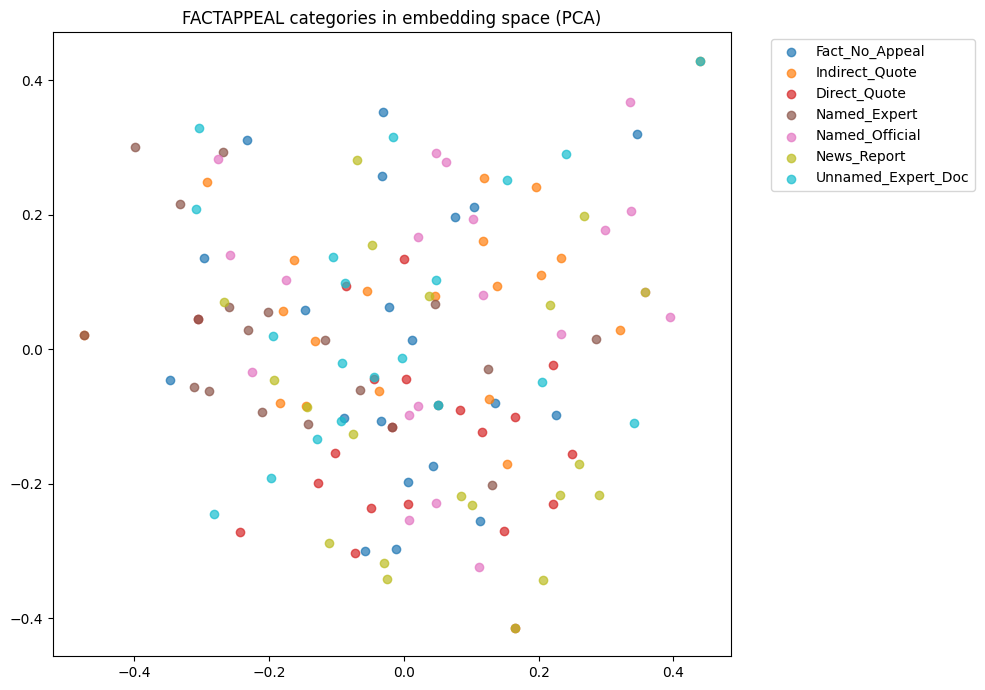

Saved plot


In [11]:
import pandas as pd
import numpy as np
import random
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

fact_df = pd.read_csv('/Users/nash/factappeal/train.csv')

# Categories with enough examples
categories = {
    'Fact_No_Appeal': 'Fact_No_Appeal',
    'Indirect_Quote': 'Fact_Appeal:Indirect_Quote',
    'Direct_Quote': 'Fact_Appeal:Direct_Quote',
    'Named_Expert': 'Appeal_Source:Named:Expert',
    'Named_Official': 'Appeal_Source:Named:Official',
    'News_Report': 'Appeal_Source:Named:News Report',
    'Unnamed_Expert_Doc': 'Appeal_Source:Unnamed:Expert Document',
}

random.seed(42)
samples = {}
for label, tag in categories.items():
    sentences = fact_df[fact_df['annotation'].str.contains(f'<{tag}', na=False)]['sentence'].tolist()
    samples[label] = random.sample(sentences, min(20, len(sentences)))
    print(f"{label}: {len(samples[label])} sentences")

# Encode
model = SentenceTransformer('all-MiniLM-L6-v2', device='mps')
all_sentences = []
all_labels = []
for label, sents in samples.items():
    all_sentences.extend(sents)
    all_labels.extend([label] * len(sents))

print("\nEncoding...")
embeddings = model.encode(all_sentences, convert_to_tensor=False, show_progress_bar=True)

# PCA down to 2D and plot
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))
for i, label in enumerate(categories.keys()):
    mask = [l == label for l in all_labels]
    x = coords[mask, 0]
    y = coords[mask, 1]
    plt.scatter(x, y, label=label, alpha=0.7, color=colors[i])

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('FACTAPPEAL categories in embedding space (PCA)')
plt.tight_layout()
plt.savefig('/Users/nash/Documents/ConspiracyComments/factappeal_clusters.png', dpi=150)
plt.show()
print("Saved plot")

In [13]:
import duckdb
con = duckdb.connect()
output_file = '/Users/nash/Documents/ConspiracyComments/lexical_scores_full.parquet'

result = con.execute(f"""
    SELECT COUNT(*) as candidates
    FROM '{output_file}'
    WHERE 
        -- Reporting verbs / attribution syntax
        lower(text) LIKE '%according to%'
        OR lower(text) LIKE '%said that%'
        OR lower(text) LIKE '%reported that%'
        OR lower(text) LIKE '%claims that%'
        OR lower(text) LIKE '%stated that%'
        OR lower(text) LIKE '%confirmed that%'
        OR lower(text) LIKE '%announced that%'
        -- Direct quote signals
        OR (text LIKE '%"%' AND (
            lower(text) LIKE '%said%'
            OR lower(text) LIKE '%wrote%'
            OR lower(text) LIKE '%according%'
        ))
""").fetchone()

print(f"Stage 1 candidates: {result[0]:,}")
print(f"That's {result[0]/21_000_000*100:.1f}% of corpus")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Stage 1 candidates: 614,888
That's 2.9% of corpus


In [15]:
results = con.execute(f"""
    SELECT text
    FROM '{output_file}'
    WHERE 
        lower(text) LIKE '%according to%'
        OR lower(text) LIKE '%said that%'
        OR lower(text) LIKE '%reported that%'
        OR lower(text) LIKE '%claims that%'
        OR lower(text) LIKE '%stated that%'
        OR lower(text) LIKE '%confirmed that%'
        OR lower(text) LIKE '%announced that%'
        OR (text LIKE '%"%' AND (
            lower(text) LIKE '%said%'
            OR lower(text) LIKE '%wrote%'
            OR lower(text) LIKE '%according%'
        ))
    USING SAMPLE 20
""").df()['text'].tolist()

for i, t in enumerate(results):
    print(f"--- {i+1} ---")
    print(t[:300])
    print()

--- 1 ---
And you taking the time to reply to a comment you deem "stupid" makes you smarter?  That said I have no idea why I'm typing this right now. I think you are looking for r/skeptic...ya neggie. 

--- 2 ---
I don't attack gaming, just your belief that complaining about Gabe counts as a meaningful comment. I game too, i just bitch about being downvoted like you have many times according to your comment threads.

--- 3 ---
> I swear I will buy you some glasses.

Did you bother to read the link I provided?  Here' I'll quote the relevant portion for you.

* high-rise building, also called high-rise,  multistory building tall enough to require the use of a system of mechanical vertical transportation such as elevators.





In [16]:
import spacy
print(spacy.__version__)

3.8.14


In [17]:
!python -m spacy download en_core_web_sm

python3.12(78157) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 4.9 MB/s  0:00:02 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [18]:
import spacy
nlp = spacy.load('en_core_web_sm')

test = "According to Dr. Fauci, the vaccine is safe and effective."
doc = nlp(test)

for token in doc:
    print(f"{token.text:15} dep={token.dep_:15} pos={token.pos_:8} head={token.head.text}")

print("\nEntities:")
for ent in doc.ents:
    print(f"  {ent.text:20} {ent.label_}")

According       dep=prep            pos=VERB     head=is
to              dep=prep            pos=ADP      head=According
Dr.             dep=compound        pos=PROPN    head=Fauci
Fauci           dep=pobj            pos=PROPN    head=to
,               dep=punct           pos=PUNCT    head=is
the             dep=det             pos=DET      head=vaccine
vaccine         dep=nsubj           pos=NOUN     head=is
is              dep=ROOT            pos=AUX      head=is
safe            dep=acomp           pos=ADJ      head=is
and             dep=cc              pos=CCONJ    head=safe
effective       dep=conj            pos=ADJ      head=safe
.               dep=punct           pos=PUNCT    head=is

Entities:
  Fauci                PERSON


In [20]:
def classify_attribution_doc(doc):
    text = doc.text
    text_lower = text.lower()
    
    has_quote = '"' in text or '\u201c' in text or '\u201d' in text
    has_reporting_verb = any(token.lemma_.lower() in REPORTING_VERBS for token in doc)
    
    persons = [ent.text for ent in doc.ents if ent.label_ == 'PERSON']
    orgs = [ent.text.lower() for ent in doc.ents if ent.label_ == 'ORG']
    
    is_news_org = any(org in NEWS_ORGS for org in orgs) or \
                  any(n in text_lower for n in NEWS_ORGS)
    is_official_org = any(org in OFFICIAL_ORGS for org in orgs) or \
                      any(o in text_lower for o in OFFICIAL_ORGS)
    is_expert_hint = any(h in text_lower for h in EXPERT_HINTS)
    has_named_source = len(persons) > 0 or len(orgs) > 0
    
    unnamed_signals = any(phrase in text_lower for phrase in [
        'sources say', 'sources told', 'officials say', 'officials told',
        'experts say', 'experts told', 'according to sources',
        'anonymous', 'who asked not to be named', 'familiar with the matter'
    ])
    
    if has_quote and has_reporting_verb and has_named_source:
        if persons:
            return 'Direct_Quote:Named'
        return 'Direct_Quote:Unnamed'
    
    if has_reporting_verb and has_named_source:
        if is_news_org:
            return 'Indirect_Quote:News_Report'
        if is_official_org:
            return 'Indirect_Quote:Named_Official'
        if is_expert_hint and persons:
            return 'Indirect_Quote:Named_Expert'
        if persons or orgs:
            return 'Indirect_Quote:Named_Other'
    
    if unnamed_signals:
        return 'Indirect_Quote:Unnamed_Source'
    
    if has_reporting_verb:
        return 'Indirect_Quote:Unattributed'
    
    return 'No_Clear_Attribution'

In [21]:
from spacy.tokens import Doc
import multiprocessing

print("Running Stage 2 spaCy classification (multiprocessing)...")
start = time.time()

texts = candidates_df['text'].str[:500].tolist()  # cap at 500 chars same as before

results = []
for doc in tqdm(nlp.pipe(texts, batch_size=256, n_process=6), total=len(texts)):
    results.append(classify_attribution_doc(doc))

candidates_df['attribution_class'] = results
elapsed = (time.time() - start) / 60
print(f"Done in {elapsed:.1f} minutes")

Running Stage 2 spaCy classification (multiprocessing)...


  0%|                                                | 0/614888 [00:00<?, ?it/s]python3.12(78221) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
python3.12(78222) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
python3.12(78223) MallocStackLogging: can't turn off malloc stack lo

Done in 30.6 minutes


In [24]:
import duckdb
spacy_output = '/Users/nash/Documents/ConspiracyComments/spacy_attributed_comments.parquet'
con = duckdb.connect()

print(con.execute(f"""
    SELECT attribution_class, COUNT(*) as n,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct
    FROM '{spacy_output}'
    GROUP BY attribution_class
    ORDER BY n DESC
""").df().to_string())

               attribution_class       n    pct
0           No_Clear_Attribution  608202  98.91
1  Indirect_Quote:Unnamed_Source    3138   0.51
2             Direct_Quote:Named    1115   0.18
3    Indirect_Quote:Unattributed    1012   0.16
4  Indirect_Quote:Named_Official     506   0.08
5           Direct_Quote:Unnamed     476   0.08
6     Indirect_Quote:News_Report     394   0.06
7     Indirect_Quote:Named_Other      40   0.01
8    Indirect_Quote:Named_Expert       5   0.00


In [23]:
spacy_output = '/Users/nash/Documents/ConspiracyComments/spacy_attributed_comments.parquet'
candidates_df.to_parquet(spacy_output, compression='zstd', index=False)
print("Saved")

Saved


In [25]:
print(con.execute(f"""
    SELECT COUNT(*) 
    FROM '{spacy_output}'
    WHERE lower(text) LIKE '%according to%'
    AND (
        lower(text) LIKE '%doctor%'
        OR lower(text) LIKE '%scientist%'
        OR lower(text) LIKE '%researcher%'
        OR lower(text) LIKE '%professor%'
        OR lower(text) LIKE '%dr.%'
        OR lower(text) LIKE '%prof.%'
    )
""").fetchone()[0])

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

12508


In [26]:
print(con.execute(f"""
    SELECT attribution_class, text[:300]
    FROM '{spacy_output}'
    WHERE lower(text) LIKE '%according to%'
    AND lower(text) LIKE '%scientist%'
    LIMIT 5
""").df().to_string())

      attribution_class                                                                                                                                                                                                                                                                                                       "text"[:300]
0  No_Clear_Attribution    I thought according to Jones et al, the ISI was behind 9/11 (the alleged wire xfter to atta).  Did he ask this clown about that?\n\nI say clown because:\nGul, 71, has acknowledged that he once was a member of a group of retired ISI officers, Pakistani scientists and others that was suspected by the Uni
1  No_Clear_Attribution       The scientists and technicians in the Manhattan Project were helping to end a war, not conspiring to murder thousands of people on our own soil. And according to the information being issued from the Cult of 9/11, there had to have been millions of people involved to pull off the conspiracy theories
2  No_C

In [27]:
# 1. Redefine the function (paste the new classify_attribution_doc from above)

# 2. Rerun the pipe
print("Rerunning with fixed classifier...")
start = time.time()
texts = candidates_df['text'].str[:500].tolist()

results = []
for doc in tqdm(nlp.pipe(texts, batch_size=256, n_process=6), total=len(texts)):
    results.append(classify_attribution_doc(doc))

candidates_df['attribution_class'] = results
elapsed = (time.time() - start) / 60
print(f"Done in {elapsed:.1f} minutes")

# 3. Overwrite the parquet
spacy_output = '/Users/nash/Documents/ConspiracyComments/spacy_attributed_comments.parquet'
candidates_df.to_parquet(spacy_output, compression='zstd', index=False)
print("Saved")

Rerunning with fixed classifier...


  0%|                                                | 0/614888 [00:00<?, ?it/s]python3.12(78643) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
python3.12(78644) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
python3.12(78645) MallocStackLogging: can't turn off malloc stack lo

Done in 29.5 minutes
Saved


In [28]:
print(con.execute(f"""
    SELECT attribution_class, COUNT(*) as n,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct
    FROM '{spacy_output}'
    GROUP BY attribution_class
    ORDER BY n DESC
""").df().to_string())

               attribution_class       n    pct
0           No_Clear_Attribution  608202  98.91
1  Indirect_Quote:Unnamed_Source    3138   0.51
2             Direct_Quote:Named    1115   0.18
3    Indirect_Quote:Unattributed    1012   0.16
4  Indirect_Quote:Named_Official     506   0.08
5           Direct_Quote:Unnamed     476   0.08
6     Indirect_Quote:News_Report     394   0.06
7     Indirect_Quote:Named_Other      40   0.01
8    Indirect_Quote:Named_Expert       5   0.00


In [29]:
import inspect
print(inspect.getsource(classify_attribution_doc))

def classify_attribution_doc(doc):
    text = doc.text
    text_lower = text.lower()

    has_quote = '"' in text or '\u201c' in text or '\u201d' in text
    has_reporting_verb = any(token.lemma_.lower() in REPORTING_VERBS for token in doc)

    persons = [ent.text for ent in doc.ents if ent.label_ == 'PERSON']
    orgs = [ent.text.lower() for ent in doc.ents if ent.label_ == 'ORG']

    is_news_org = any(org in NEWS_ORGS for org in orgs) or \
                  any(n in text_lower for n in NEWS_ORGS)
    is_official_org = any(org in OFFICIAL_ORGS for org in orgs) or \
                      any(o in text_lower for o in OFFICIAL_ORGS)
    is_expert_hint = any(h in text_lower for h in EXPERT_HINTS)
    has_named_source = len(persons) > 0 or len(orgs) > 0

    unnamed_signals = any(phrase in text_lower for phrase in [
        'sources say', 'sources told', 'officials say', 'officials told',
        'experts say', 'experts told', 'according to sources',
        'anonymous', 'who asked not t

In [2]:
import duckdb
import time
import spacy
from tqdm import tqdm

con = duckdb.connect()
nlp = spacy.load('en_core_web_sm')

output_file = '/Users/nash/Documents/ConspiracyComments/lexical_scores_full.parquet'
spacy_output = '/Users/nash/Documents/ConspiracyComments/spacy_attributed_comments.parquet'

NEWS_ORGS = {
    'reuters', 'bbc', 'cnn', 'nyt', 'new york times', 'washington post',
    'guardian', 'associated press', 'ap', 'fox news', 'msnbc', 'abc',
    'nbc', 'cbs', 'bloomberg', 'huffington post', 'breitbart', 'infowars',
    'daily mail', 'the hill', 'politico', 'vice', 'buzzfeed', 'epoch times'
}
OFFICIAL_ORGS = {
    'cdc', 'fbi', 'cia', 'nsa', 'who', 'fda', 'nasa', 'pentagon',
    'white house', 'congress', 'senate', 'un', 'united nations',
    'department of', 'ministry of', 'government'
}
EXPERT_HINTS = {
    'doctor', 'dr.', 'professor', 'prof.', 'researcher', 'scientist',
    'expert', 'analyst', 'psychiatrist', 'epidemiologist', 'virologist',
    'study', 'research', 'journal', 'university', 'institute'
}
REPORTING_VERBS = {
    'said', 'says', 'stated', 'claims', 'claimed', 'reported',
    'confirmed', 'announced', 'wrote', 'writes', 'according',
    'noted', 'found', 'concluded', 'showed', 'suggests'
}

def classify_attribution_doc(doc):
    text = doc.text
    text_lower = text.lower()

    has_quote = '"' in text or '\u201c' in text or '\u201d' in text
    has_reporting_verb = any(token.lemma_.lower() in REPORTING_VERBS for token in doc)

    persons = [ent.text for ent in doc.ents if ent.label_ == 'PERSON']
    orgs = [ent.text.lower() for ent in doc.ents if ent.label_ == 'ORG']

    is_news_org = any(org in NEWS_ORGS for org in orgs) or \
                  any(n in text_lower for n in NEWS_ORGS)
    is_official_org = any(org in OFFICIAL_ORGS for org in orgs) or \
                      any(o in text_lower for o in OFFICIAL_ORGS)
    is_expert_hint = any(h in text_lower for h in EXPERT_HINTS)
    has_named_source = len(persons) > 0 or len(orgs) > 0

    unnamed_signals = any(phrase in text_lower for phrase in [
        'sources say', 'sources told', 'officials say', 'officials told',
        'experts say', 'experts told', 'according to sources',
        'anonymous', 'who asked not to be named', 'familiar with the matter'
    ])

    if has_quote and has_reporting_verb and (has_named_source or is_expert_hint):
        if persons:
            return 'Direct_Quote:Named'
        if is_expert_hint:
            return 'Direct_Quote:Expert'
        return 'Direct_Quote:Unnamed'

    if has_reporting_verb:
        if is_news_org:
            return 'Indirect_Quote:News_Report'
        if is_official_org:
            return 'Indirect_Quote:Named_Official'
        if is_expert_hint:
            if persons:
                return 'Indirect_Quote:Named_Expert'
            return 'Indirect_Quote:Unnamed_Expert'
        if has_named_source:
            return 'Indirect_Quote:Named_Other'

    if unnamed_signals:
        return 'Indirect_Quote:Unnamed_Source'

    if has_reporting_verb:
        return 'Indirect_Quote:Unattributed'

    return 'No_Clear_Attribution'

print("All setup done, function defined correctly")

All setup done, function defined correctly


In [3]:
candidates_df = con.execute(f"""
    SELECT id, author, upvotes, controversiality, created_utc,
           hedge_count, certainty_count, evidence_count,
           authority_count, rhetorical_count, text
    FROM '{output_file}'
    WHERE 
        lower(text) LIKE '%according to%'
        OR lower(text) LIKE '%said that%'
        OR lower(text) LIKE '%reported that%'
        OR lower(text) LIKE '%claims that%'
        OR lower(text) LIKE '%stated that%'
        OR lower(text) LIKE '%confirmed that%'
        OR lower(text) LIKE '%announced that%'
        OR (text LIKE '%"%' AND (
            lower(text) LIKE '%said%'
            OR lower(text) LIKE '%wrote%'
            OR lower(text) LIKE '%according%'
        ))
""").df()
print(f"Loaded {len(candidates_df):,} candidates")

print("Running spaCy classification...")
start = time.time()
texts = candidates_df['text'].str[:500].tolist()

results = []
for doc in tqdm(nlp.pipe(texts, batch_size=256, n_process=6), total=len(texts)):
    results.append(classify_attribution_doc(doc))

candidates_df['attribution_class'] = results
elapsed = (time.time() - start) / 60
print(f"Done in {elapsed:.1f} minutes")

candidates_df.to_parquet(spacy_output, compression='zstd', index=False)
print("Saved")

print(con.execute(f"""
    SELECT attribution_class, COUNT(*) as n,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct
    FROM '{spacy_output}'
    GROUP BY attribution_class
    ORDER BY n DESC
""").df().to_string())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded 614,888 candidates
Running spaCy classification...


100%|██████████████████████████████████| 614888/614888 [30:58<00:00, 330.86it/s]


Done in 31.0 minutes
Saved
                attribution_class       n    pct
0            No_Clear_Attribution  608202  98.91
1   Indirect_Quote:Unnamed_Source    3135   0.51
2              Direct_Quote:Named    1115   0.18
3   Indirect_Quote:Named_Official    1017   0.17
4      Indirect_Quote:News_Report     707   0.11
5            Direct_Quote:Unnamed     426   0.07
6     Indirect_Quote:Unattributed     144   0.02
7             Direct_Quote:Expert      92   0.01
8      Indirect_Quote:Named_Other      36   0.01
9   Indirect_Quote:Unnamed_Expert       9   0.00
10    Indirect_Quote:Named_Expert       5   0.00


In [4]:
import spacy
nlp2 = spacy.load('en_core_web_sm')
test = "According to scientists, the vaccine causes autism."
doc = nlp2(test)
for token in doc:
    print(f"{token.text:15} lemma={token.lemma_:15}")
print([token.lemma_.lower() for token in doc if token.lemma_.lower() in REPORTING_VERBS])

According       lemma=accord         
to              lemma=to             
scientists      lemma=scientist      
,               lemma=,              
the             lemma=the            
vaccine         lemma=vaccine        
causes          lemma=cause          
autism          lemma=autism         
.               lemma=.              
[]


In [5]:
import spacy
nlp = spacy.load('en_core_web_sm')

test = "According to scientists, the vaccine causes autism."
doc = nlp(test)

for token in doc:
    print(f"Text: {token.text:15} | Lemma: {token.lemma_:15} | POS: {token.pos_}")

Text: According       | Lemma: accord          | POS: VERB
Text: to              | Lemma: to              | POS: ADP
Text: scientists      | Lemma: scientist       | POS: NOUN
Text: ,               | Lemma: ,               | POS: PUNCT
Text: the             | Lemma: the             | POS: DET
Text: vaccine         | Lemma: vaccine         | POS: NOUN
Text: causes          | Lemma: cause           | POS: VERB
Text: autism          | Lemma: autism          | POS: NOUN
Text: .               | Lemma: .               | POS: PUNCT


In [6]:
REPORTING_VERBS = {
    'say', 'said', 'says', 
    'state', 'stated', 'states',
    'claim', 'claims', 'claimed', 
    'report', 'reports', 'reported',
    'confirm', 'confirms', 'confirmed', 
    'announce', 'announces', 'announced', 
    'write', 'writes', 'wrote', 
    'accord', 'according',  # The missing link
    'note', 'notes', 'noted', 
    'find', 'finds', 'found', 
    'conclude', 'concludes', 'concluded', 
    'show', 'shows', 'showed', 
    'suggest', 'suggests', 'suggested'
}

In [7]:
print("Running spaCy classification with fixed lemmas...")
start = time.time()
texts = candidates_df['text'].str[:500].tolist()

results = []
for doc in tqdm(nlp.pipe(texts, batch_size=256, n_process=6), total=len(texts)):
    results.append(classify_attribution_doc(doc))

candidates_df['attribution_class'] = results
elapsed = (time.time() - start) / 60
print(f"Done in {elapsed:.1f} minutes")

candidates_df.to_parquet(spacy_output, compression='zstd', index=False)
print("Saved")

Running spaCy classification with fixed lemmas...


100%|██████████████████████████████████| 614888/614888 [29:23<00:00, 348.74it/s]


Done in 29.5 minutes
Saved


In [8]:
import duckdb
spacy_output = '/Users/nash/Documents/ConspiracyComments/spacy_attributed_comments.parquet'
con = duckdb.connect()

print(con.execute(f"""
    SELECT attribution_class, COUNT(*) as n,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct
    FROM '{spacy_output}'
    GROUP BY attribution_class
    ORDER BY n DESC
""").df().to_string())

                attribution_class       n    pct
0   Indirect_Quote:Named_Official  139342  22.66
1              Direct_Quote:Named  134889  21.94
2      Indirect_Quote:News_Report  111579  18.15
3            No_Clear_Attribution   73014  11.87
4     Indirect_Quote:Unattributed   58581   9.53
5            Direct_Quote:Unnamed   53717   8.74
6      Indirect_Quote:Named_Other   24315   3.95
7             Direct_Quote:Expert   15072   2.45
8   Indirect_Quote:Unnamed_Expert    2722   0.44
9     Indirect_Quote:Named_Expert    1269   0.21
10  Indirect_Quote:Unnamed_Source     388   0.06


In [9]:
print(con.execute(f"""
    SELECT 
        attribution_class,
        COUNT(*) as n,
        ROUND(AVG(upvotes), 2) as avg_upvotes,
        ROUND(MEDIAN(upvotes), 2) as median_upvotes,
        ROUND(AVG(controversiality), 3) as avg_controversy
    FROM '{spacy_output}'
    GROUP BY attribution_class
    ORDER BY avg_upvotes DESC
""").df().to_string())

                attribution_class       n  avg_upvotes  median_upvotes  avg_controversy
0   Indirect_Quote:Unnamed_Source     388         7.01             2.0            0.070
1              Direct_Quote:Named  134889         6.30             2.0            0.084
2            No_Clear_Attribution   73014         5.97             2.0            0.067
3            Direct_Quote:Unnamed   53717         5.38             2.0            0.076
4      Indirect_Quote:Named_Other   24315         5.24             2.0            0.080
5      Indirect_Quote:News_Report  111579         5.06             2.0            0.073
6   Indirect_Quote:Named_Official  139342         5.03             2.0            0.074
7             Direct_Quote:Expert   15072         4.98             2.0            0.069
8   Indirect_Quote:Unnamed_Expert    2722         4.59             1.0            0.077
9     Indirect_Quote:Unattributed   58581         4.38             1.0            0.070
10    Indirect_Quote:Named_Exper

In [10]:
import duckdb

con = duckdb.connect()
spacy_output = '/Users/nash/Documents/ConspiracyComments/spacy_attributed_comments.parquet'

# The buckets we want to eyeball
categories_to_check = [
    'Indirect_Quote:Named_Expert',
    'Direct_Quote:Expert',
    'Indirect_Quote:Unnamed_Source',
    'Indirect_Quote:Named_Official'
]

for cat in categories_to_check:
    print(f"\n{'='*60}")
    print(f"CATEGORY: {cat}")
    print(f"{'='*60}\n")
    
    # Grab 3 random comments from the bucket
    results = con.execute(f"""
        SELECT text 
        FROM '{spacy_output}' 
        WHERE attribution_class = '{cat}'
        ORDER BY RANDOM()
        LIMIT 3
    """).df()['text'].tolist()
    
    for i, text in enumerate(results):
        # Print the first 400 characters to keep it readable
        clean_text = text[:400].replace('\n', ' ')
        print(f"[{i+1}] {clean_text}...\n")


CATEGORY: Indirect_Quote:Named_Expert

[1] George Orwell said that journalism is printing what someone else does not want printed; everything else is public relations....

[2] Idiot. If Trump were to die at the hands of a leftist and the public were to realize it's because of hateful individuals such as Don Trump died then there will be violent confrontations.  People are already verbally confronting the media heads on the streets for the lies.  These champagne sipping liberals are so out of touch, even Moore said that  the Media was out of touch with Trump. Moore did s...

[3] The Daily Beast:  [**‘Safer’ OxyContin Caused Thousands of Heroin Deaths, Researchers Find**](http://www.thedailybeast.com/articles/2017/01/14/safer-oxycontin-caused-7-500-heroin-deaths-researchers-find)  Psychology Today:  [Connecting Dots Between The Opioid Epidemic and Philanthropy](https://www.psychologytoday.com/blog/saving-normal/201610/connecting-dots-between-the-opioid-epidemic-and-philant...


CATEGORY

In [11]:
import duckdb

con = duckdb.connect()
spacy_output = '/Users/nash/Documents/ConspiracyComments/spacy_attributed_comments.parquet'

categories_to_check = [
    'Indirect_Quote:Named_Expert',
    'Direct_Quote:Expert',
    'Indirect_Quote:Unnamed_Source',
    'Indirect_Quote:Named_Official'
]

for cat in categories_to_check:
    print(f"\n{'='*80}")
    print(f"CATEGORY: {cat}")
    print(f"{'='*80}\n")
    
    results = con.execute(f"""
        SELECT text 
        FROM '{spacy_output}' 
        WHERE attribution_class = '{cat}'
        ORDER BY RANDOM()
        LIMIT 3
    """).df()['text'].tolist()
    
    for i, text in enumerate(results):
        print(f"[{i+1}]\n{text}\n")
        print("-" * 40)


CATEGORY: Indirect_Quote:Named_Expert

[1]
That excerpt - from 1976 btw - is wrong.  Flat-out, blatantly, completely incorrect.  [Read this](http://www.pnas.org/content/96/4/1651).  Its an actual peer-reviewed article from a respected journal.  It comes to some interesting conclusions regarding the origins of the 1918 Spanish Flu, and directly contradicts many of the (incorrect) claims made in your link.  For example, your link claims that no samples of the original virus exist.  This is clearly completely false, considering the researchers in my article have completely sequenced the RNA of the virus.  

You are, once again, using faulty evidence to support your own viewpoints, in this case that the Spanish Flu of 1918 was vaccine-caused, therefore allowing you to attribute the influenza deaths to it.  Read the article, and understand that it is based on real, provable science.  

Now, back to my question.  What evidence can you provide to support your claim that the new H1N1 vaccine 

In [12]:
import pandas as pd
import ast

# Load the active learning output
FILE_PATH = '/Users/nash/Documents/ConspiracyComments/human_labels_active_learning.csv'
df = pd.read_csv(FILE_PATH)

# Convert string representation of lists back to real Python lists
df['epistemic_moves'] = df['epistemic_moves'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# Explode the lists so each epistemic move gets its own row, preserving the stance
exploded_df = df.explode('epistemic_moves')

# Generate a cross-tabulation matrix (Counts)
matrix_counts = pd.crosstab(
    index=exploded_df['epistemic_moves'], 
    columns=exploded_df['human_stance'], 
    margins=True, 
    margins_name="Total"
).sort_values(by='Total', ascending=False)

# Generate a cross-tabulation matrix (Percentages by row to see the skew easily)
matrix_pct = pd.crosstab(
    index=exploded_df['epistemic_moves'], 
    columns=exploded_df['human_stance'], 
    normalize='index'
) * 100

print("=== ABSOLUTE COUNTS ===")
print(matrix_counts)
print("\n=== ROW PERCENTAGES (SKEW DETECTOR) ===")
print(matrix_pct.round(1).to_string() + " %")

=== ABSOLUTE COUNTS ===
human_stance                         Anti-Conspiracy  Neutral / Unclear  \
epistemic_moves                                                           
Total                                             37                  9   
Quoting Parent                                     9                  0   
Direct Quote (External)                            5                  1   
Appeal to Logic                                    5                  1   
Link                                               4                  0   
Direct Quote (Named Official)                      3                  1   
Generalisation                                     2                  1   
Demand Evidence                                    2                  0   
Quote News Media                                   0                  0   
Rhetorical Question                                1                  0   
Gish Gallop                                        0                  0   
I

In [15]:
import duckdb
import time

# --- File Paths ---
POSTS_PATTERN = '/Users/nash/Documents/ConspiracyComments/r_conspiracy_posts*.jsonl'
COMMENTS_PARQUET = '/Users/nash/Documents/ConspiracyComments/lexical_scores_full.parquet'
OUTPUT_FILE = '/Users/nash/Documents/ConspiracyComments/master_thread_synthesis.parquet'

con = duckdb.connect()

print("Initiating Master Synthesis Join...")
print("Aggregating 21 million comments and mapping them to their parent submissions.")
print("Go to sleep. This will be ready in the morning.")

start_time = time.time()

query = f"""
COPY (
    WITH comment_aggregates AS (
        -- Step 1: Compress the 21 million comments down to the thread level
        SELECT 
            -- Reddit comment link_ids start with 't3_' followed by the post ID
            REPLACE(link_id, 't3_', '') as post_id,
            COUNT(*) as total_comments,
            ROUND(AVG(upvotes), 2) as avg_comment_upvotes,
            ROUND(AVG(controversiality), 4) as avg_controversiality,
            
            -- Average the Epistemic Lexical Scores for the entire thread
            ROUND(AVG(evidence_count), 3) as avg_evidence_score,
            ROUND(AVG(rhetorical_count), 3) as avg_rhetoric_score,
            ROUND(AVG(certainty_count), 3) as avg_certainty_score,
            ROUND(AVG(authority_count), 3) as avg_authority_score,
            ROUND(AVG(hedge_count), 3) as avg_hedge_score
        FROM '{COMMENTS_PARQUET}'
        WHERE link_id IS NOT NULL
        GROUP BY REPLACE(link_id, 't3_', '')
    ),
    post_data AS (
        -- Step 2: Extract the clean submission data
        SELECT 
            id as post_id,
            created_utc,
            author as post_author,
            title,
            url,
            domain,
            score as post_score
        FROM read_json_auto('{POSTS_PATTERN}', union_by_name=true, ignore_errors=true)
        WHERE domain IS NOT NULL 
          AND domain != 'self.conspiracy'
    )
    
    -- Step 3: The Master Join
    SELECT 
        p.post_id,
        p.created_utc,
        p.title,
        p.domain,
        p.url,
        p.post_score,
        c.total_comments,
        c.avg_comment_upvotes,
        c.avg_controversiality,
        c.avg_evidence_score,
        c.avg_rhetoric_score,
        c.avg_certainty_score,
        c.avg_authority_score,
        c.avg_hedge_score
    FROM post_data p
    INNER JOIN comment_aggregates c ON p.post_id = c.post_id
) TO '{OUTPUT_FILE}' (FORMAT PARQUET, COMPRESSION 'zstd');
"""

con.execute(query)

elapsed = (time.time() - start_time) / 60
print(f"\nSUCCESS: Master Synthesis complete in {elapsed:.1f} minutes.")
print(f"Unified data saved safely to: {OUTPUT_FILE}")

Initiating Master Synthesis Join...
Aggregating 21 million comments and mapping them to their parent submissions.
Go to sleep. This will be ready in the morning.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


SUCCESS: Master Synthesis complete in 0.1 minutes.
Unified data saved safely to: /Users/nash/Documents/ConspiracyComments/master_thread_synthesis.parquet


In [14]:
import duckdb

con = duckdb.connect()
output_file = '/Users/nash/Documents/ConspiracyComments/lexical_scores_full.parquet'

# Extract all URLs and their domains, with upvotes
print(con.execute(f"""
    WITH urls AS (
        SELECT 
            id,
            upvotes,
            controversiality,
            -- Extract the full URL
            UNNEST(regexp_extract_all(text, 'https?://[^\s\)\]"]+')) AS url
        FROM '{output_file}'
        WHERE text LIKE '%http%'
    ),
    domains AS (
        SELECT
            id,
            upvotes,
            controversiality,
            url,
            -- Extract just the domain
            regexp_extract(url, 'https?://(?:www\.)?([^/\s]+)') AS domain
        FROM urls
    )
    SELECT 
        domain,
        COUNT(*) as citations,
        ROUND(AVG(upvotes), 2) as avg_upvotes,
        ROUND(MEDIAN(upvotes), 2) as median_upvotes,
        ROUND(AVG(controversiality), 3) as avg_controversy,
        COUNT(DISTINCT id) as unique_comments
    FROM domains
    WHERE domain != ''
      AND length(domain) > 3
    GROUP BY domain
    ORDER BY citations DESC
    LIMIT 50
""").df().to_string())

<>:48: SyntaxWarning: invalid escape sequence '\s'
<>:51: SyntaxWarning: invalid escape sequence '\.'
<>:48: SyntaxWarning: invalid escape sequence '\s'
<>:51: SyntaxWarning: invalid escape sequence '\.'
/var/folders/ym/6mr3ypl97rj6468b4m65lq240000gp/T/ipykernel_79142/4216252512.py:48: SyntaxWarning: invalid escape sequence '\s'
/var/folders/ym/6mr3ypl97rj6468b4m65lq240000gp/T/ipykernel_79142/4216252512.py:51: SyntaxWarning: invalid escape sequence '\.'


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                             domain  citations  avg_upvotes  median_upvotes  avg_controversy  unique_comments
0            https://www.reddit.com    2475946         1.32             1.0            0.005          1298010
1           https://www.youtube.com     245849         5.54             2.0            0.065           158502
2          https://en.wikipedia.org     153453         5.92             2.0            0.062           101099
3                  https://youtu.be     149249         5.51             2.0            0.068           108728
4             https://np.reddit.com     115107         4.09             1.0            0.024            48568
5               https://twitter.com      58882         8.87             2.0            0.131            41644
6                https://archive.is      58856         5.27             1.0            0.050            49655
7               https://i.imgur.com      48922         6.44             1.0            0.077            27549
8        h

In [16]:
import duckdb
import pandas as pd

# Set pandas to show all columns so nothing gets cut off in the terminal
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

con = duckdb.connect()
FILE_PATH = '/Users/nash/Documents/ConspiracyComments/master_thread_synthesis.parquet'

print("--- FILE OVERVIEW ---")
# Check how many unique threads survived the join
count_query = f"SELECT COUNT(*) as total_threads FROM '{FILE_PATH}'"
print(f"Total Threads: {con.execute(count_query).fetchone()[0]:,}\n")

print("--- TOP 10 THREADS BY COMMENT VOLUME ---")
# Pull the most engaged threads to verify the data structure
preview_query = f"""
SELECT 
    domain,
    title,
    post_score,
    total_comments,
    avg_evidence_score,
    avg_rhetoric_score,
    avg_certainty_score
FROM '{FILE_PATH}'
ORDER BY total_comments DESC
LIMIT 10
"""
df = con.execute(preview_query).df()

# Truncate the title just so it prints cleanly in the terminal
df['title'] = df['title'].apply(lambda x: (x[:75] + '...') if isinstance(x, str) and len(x) > 75 else x)

print(df.to_string(index=False))

--- FILE OVERVIEW ---
Total Threads: 888,846

--- TOP 10 THREADS BY COMMENT VOLUME ---
            domain                                                                          title  post_score  total_comments  avg_evidence_score  avg_rhetoric_score  avg_certainty_score
         i.redd.it                                            Breaking: FBI has raided Mar-A-Lago        7484            2468               0.077               0.305                0.055
        google.com                Sources: Jeffrey Epstein dies by suicide in Manhattan jail cell       32373            2391               0.117               0.284                0.061
         i.redd.it Photo of Kenosha shooting victim holding gun actively being scrubbed from t...        7348            2260               0.138               0.355                0.068
         i.redd.it This is not a “shooting victim” he’s an armed combatant that lost in a fire...        9363            2243               0.126               0.323